In [55]:
!pip install torchmetrics kagglehub albumentations lxml

import os
import cv2
import torch
import random
import kagglehub
import numpy as np
import torchvision
import albumentations as A
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tabulate import tabulate
from tqdm.autonotebook import tqdm

In [56]:
class TrafficSignDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.root_dir = root_dir
        self.split = split
        self.image_dir = os.path.join(root_dir, 'images', split)
        self.label_dir = os.path.join(root_dir, 'labels', split)

        self.image_files = [f for f in os.listdir(self.image_dir) if f.endswith('.png') or f.endswith('.jpg')]

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        img_tensor = torch.as_tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_name)

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    if len(line.strip()) == 0: continue
                    class_id, x_center, y_center, width, height = map(float, line.strip().split())

                    x_center, width = x_center * w, width * w
                    y_center, height = y_center * h, height * h

                    xmin = x_center - (width / 2)
                    ymin = y_center - (height / 2)
                    xmax = x_center + (width / 2)
                    ymax = y_center + (height / 2)

                    boxes.append([xmin, ymin, xmax, ymax])

                    labels.append(int(class_id) + 1)

        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes = torch.empty((0, 4), dtype=torch.float32)
            labels = torch.empty((0,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])

        return img_tensor, target

    def __len__(self):
        return len(self.image_files)

def collate_fn(batch):
    return tuple(zip(*batch))

In [57]:
DATA_DIR = '/kaggle/input/datasets/adithyamenonr/traffic-sign-dataset/traffic_sign_dataset'
NUM_CLASSES = 5

In [58]:
train_dataset = TrafficSignDataset(DATA_DIR, split='train')
val_dataset = TrafficSignDataset(DATA_DIR, split='val')

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, collate_fn=collate_fn)

In [59]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print(f"Model loaded and ready on {device}. Training images: {len(train_dataset)}, Validation images: {len(val_dataset)}")

Model loaded and ready on cuda. Training images: 701, Validation images: 176


In [60]:
save_path = 'faster_rcnn_traffic_signs.pth'
num_epochs = 20

train_losses = []
map_scores = []
map_50_scores = []

if os.path.exists(save_path):
    print(f"Found existing weights at '{save_path}'. Loading them into the model...")
    model.load_state_dict(torch.load(save_path, map_location=device))
    print("Weights loaded successfully!")
    should_train = False
else:
    print(f"No existing weights found at '{save_path}'.")
    print("Starting training from scratch...")
    should_train = True

No existing weights found at 'faster_rcnn_traffic_signs.pth'.
Starting training from scratch...


In [61]:
if should_train:
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for images, targets in loop:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            epoch_loss += losses.item()
            loop.set_postfix(loss=losses.item())

        lr_scheduler.step()

        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()

        metric = MeanAveragePrecision(iou_type="bbox")

        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
        with torch.no_grad():
            for images, targets in val_loop:
                images = list(image.to(device) for image in images)
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

                outputs = model(images)

                metric.update(outputs, targets)

        val_results = metric.compute()
        epoch_map = val_results['map'].item()
        epoch_map_50 = val_results['map_50'].item()

        map_scores.append(epoch_map)
        map_50_scores.append(epoch_map_50)

        print(f"Epoch #{epoch+1} Summary | Avg Train Loss: {avg_train_loss:.4f} | mAP: {epoch_map:.4f} | mAP@0.5: {epoch_map_50:.4f}\n")

    torch.save(model.state_dict(), save_path)
    print(f"\nModel weights successfully saved to: {save_path}")
else:
    print("Skipping training loop as pre-trained weights were already loaded.")

Epoch 1/20 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch #1 Summary | Avg Train Loss: 0.2565 | mAP: 0.4331 | mAP@0.5: 0.6395



Epoch 2/20 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/20 [Val]:   0%|          | 0/22 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch #19 Summary | Avg Train Loss: 0.0622 | mAP: 0.6796 | mAP@0.5: 0.8819



Epoch 20/20 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch #20 Summary | Avg Train Loss: 0.0622 | mAP: 0.6796 | mAP@0.5: 0.8819


Model weights successfully saved to: faster_rcnn_traffic_signs.pth


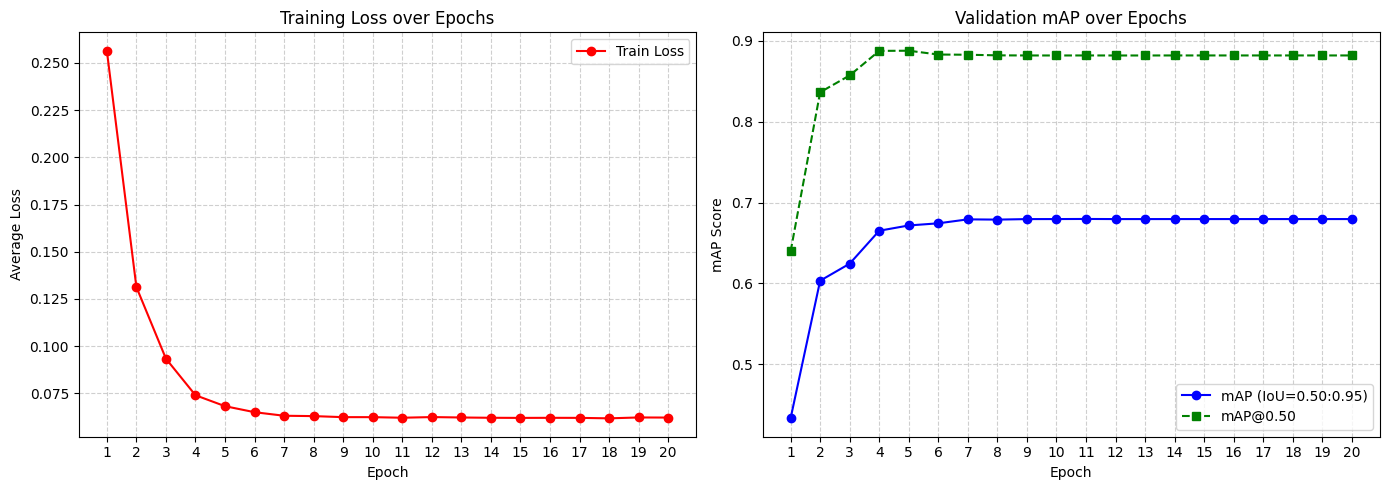

In [62]:
if should_train and len(train_losses) > 0:
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', color='red', label='Train Loss')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Average Loss')
    plt.xticks(range(1, num_epochs + 1))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs + 1), map_scores, marker='o', linestyle='-', color='blue', label='mAP (IoU=0.50:0.95)')
    plt.plot(range(1, num_epochs + 1), map_50_scores, marker='s', linestyle='--', color='green', label='mAP@0.50')
    plt.title('Validation mAP over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('mAP Score')
    plt.xticks(range(1, num_epochs + 1))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No new training data to plot. The model is using pre-loaded weights.")

In [63]:
model.eval()

metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)
metric_50 = MeanAveragePrecision(iou_type="bbox", class_metrics=True, iou_thresholds=[0.5])

CONF_THRESH = 0.5
IOU_THRESH = 0.5

class_names = ['background', 'crosswalk', 'speedlimit', 'stop', 'trafficlight']
NUM_CLASSES = len(class_names)

tp_per_class = {c: 0 for c in range(1, NUM_CLASSES)}
fp_per_class = {c: 0 for c in range(1, NUM_CLASSES)}
fn_per_class = {c: 0 for c in range(1, NUM_CLASSES)}

In [64]:
print("Evaluating on validation set...")
with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)

        metric.update(outputs, targets)
        metric_50.update(outputs, targets)

        for out, tgt in zip(outputs, targets):
            pred_boxes = out['boxes'].cpu()
            pred_scores = out['scores'].cpu()
            pred_labels = out['labels'].cpu()

            gt_boxes = tgt['boxes'].cpu()
            gt_labels = tgt['labels'].cpu()

            keep = pred_scores >= CONF_THRESH
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]
            pred_scores = pred_scores[keep]

            for c in range(1, NUM_CLASSES):
                c_pred_boxes = pred_boxes[pred_labels == c]
                c_pred_scores = pred_scores[pred_labels == c]
                c_gt_boxes = gt_boxes[gt_labels == c]

                fn_per_class[c] += len(c_gt_boxes)

                if len(c_pred_boxes) == 0: continue
                if len(c_gt_boxes) == 0:
                    fp_per_class[c] += len(c_pred_boxes)
                    continue

                ious = torchvision.ops.box_iou(c_pred_boxes, c_gt_boxes)
                matched_gt = set()

                indices = torch.argsort(c_pred_scores, descending=True)
                c_pred_boxes = c_pred_boxes[indices]
                ious = ious[indices]

                for i in range(len(c_pred_boxes)):
                    best_iou = 0
                    best_gt_idx = -1

                    for j in range(len(c_gt_boxes)):
                        if j not in matched_gt and ious[i, j] > best_iou:
                            best_iou = ious[i, j]
                            best_gt_idx = j

                    if best_iou >= IOU_THRESH:
                        tp_per_class[c] += 1
                        matched_gt.add(best_gt_idx)
                    else:
                        fp_per_class[c] += 1

                fn_per_class[c] -= len(matched_gt)

results = metric.compute()
results_50 = metric_50.compute()

Evaluating on validation set...


Evaluating:   0%|          | 0/22 [00:00<?, ?it/s]

In [65]:
map_all = results['map'].item()
map50_all = results['map_50'].item()

tp_all = sum(tp_per_class.values())
fp_all = sum(fp_per_class.values())
fn_all = sum(fn_per_class.values())

p_all = tp_all / (tp_all + fp_all) if (tp_all + fp_all) > 0 else 0.0
r_all = tp_all / (tp_all + fn_all) if (tp_all + fn_all) > 0 else 0.0
instances_all = tp_all + fn_all

map_classes = results['classes'].tolist() if 'classes' in results else []
map_per_class_vals = results['map_per_class'].tolist() if 'map_per_class' in results else []

map50_per_class_vals = results_50['map_per_class'].tolist() if 'map_per_class' in results_50 else []

map_dict = {int(c): v for c, v in zip(map_classes, map_per_class_vals)}
map50_dict = {int(c): v for c, v in zip(map_classes, map50_per_class_vals)}

In [66]:
class_names = ['background', 'crosswalk', 'speedlimit', 'stop', 'trafficlight']

colors = {
    1: (0, 51, 153),     # Dark Navy Blue for crosswalk
    2: (0, 128, 128),    # Dark Cyan for speedlimit
    3: (178, 34, 34),    # Dark Red for stop
    4: (34, 139, 34)     # Forest Green for trafficlight
}

In [67]:
def visualize_predictions(model, dataset, device, num_images=16, conf_threshold=0.5):
    model.eval()

    fig, axes = plt.subplots(4, 4, figsize=(16, 12))
    axes = axes.flatten()

    indices = random.sample(range(len(dataset)), num_images)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            img_tensor, target = dataset[idx]

            prediction = model([img_tensor.to(device)])[0]

            img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
            img_np = (img_np * 255).astype(np.uint8)
            img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

            boxes = prediction['boxes'].cpu().numpy()
            scores = prediction['scores'].cpu().numpy()
            labels = prediction['labels'].cpu().numpy()

            for box, score, label in zip(boxes, scores, labels):
                if score >= conf_threshold:
                    xmin, ymin, xmax, ymax = map(int, box)
                    color = colors.get(label, (255, 255, 255))
                    name = class_names[label]
                    text = f"{name} {score:.2f}"

                    cv2.rectangle(img_np, (xmin, ymin), (xmax, ymax), color, 2)

                    (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                    cv2.rectangle(img_np, (xmin, ymin - text_h - 5), (xmin + text_w, ymin), color, -1)

                    cv2.putText(img_np, text, (xmin, ymin - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

            img_np = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)

            axes[i].imshow(img_np)
            axes[i].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.show()

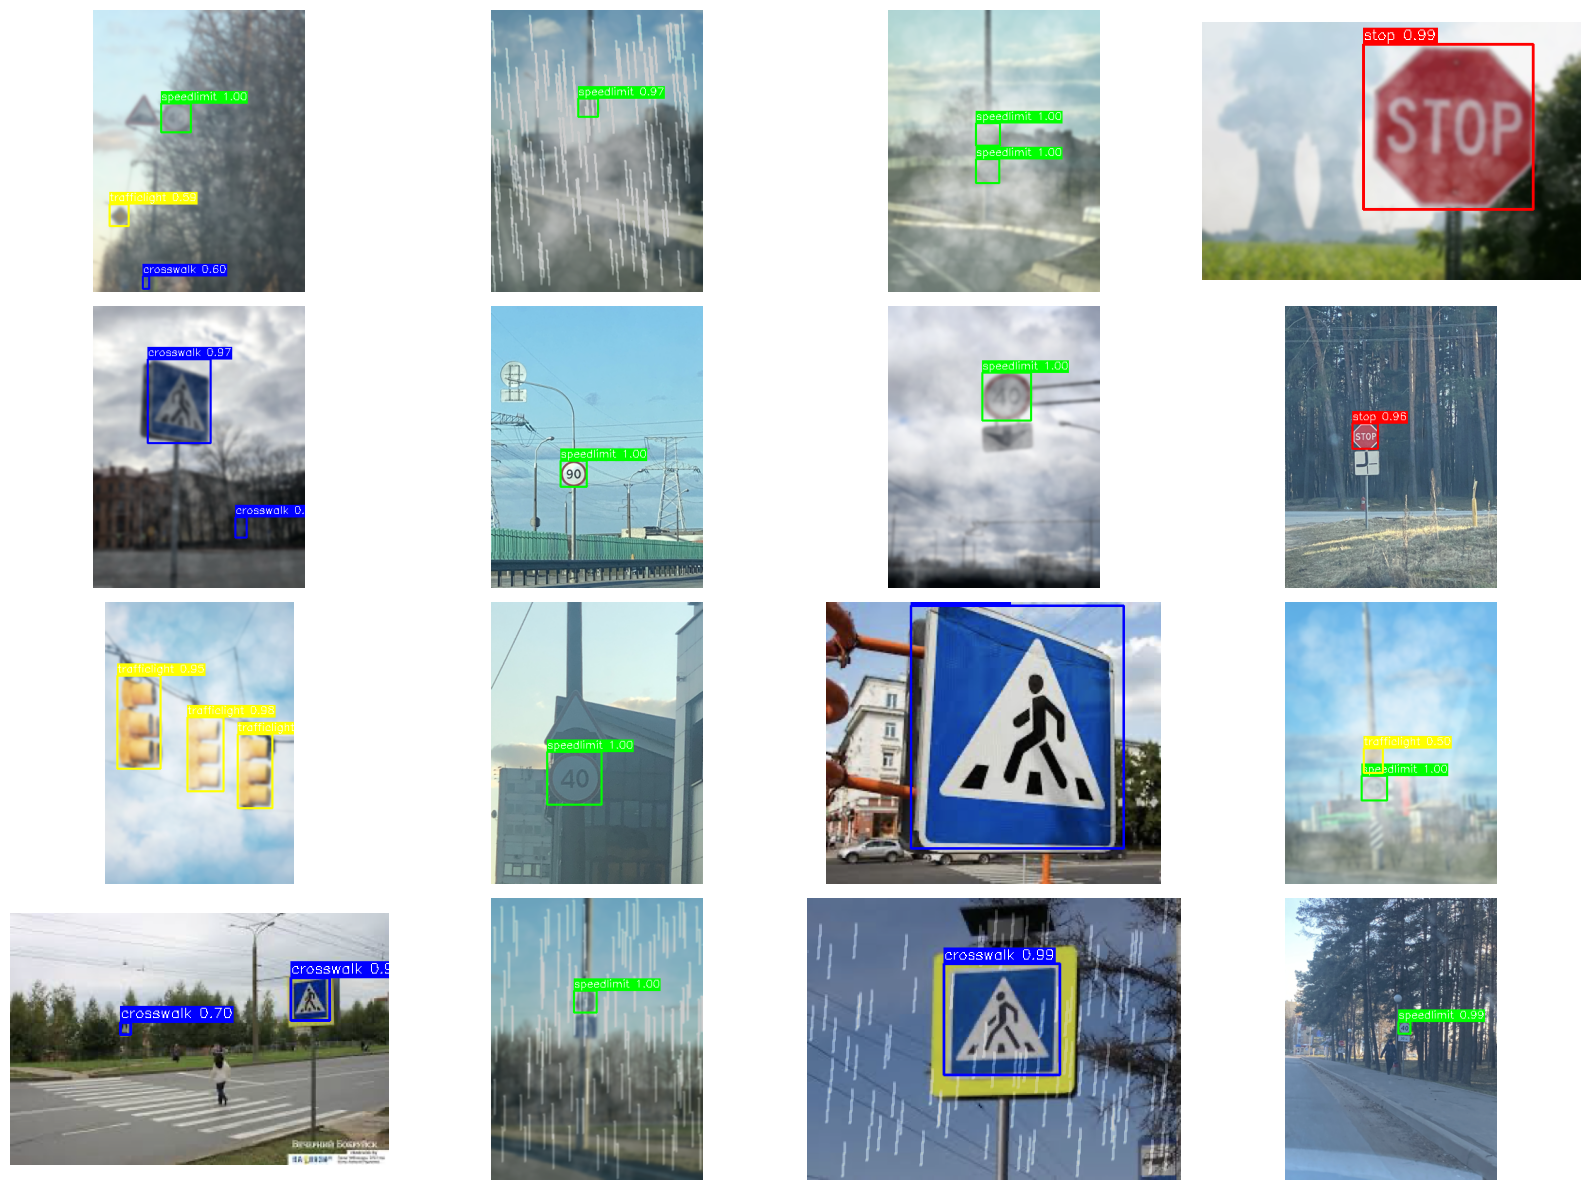

In [91]:
visualize_predictions(model, val_dataset, device, num_images=16, conf_threshold=0.5)

In [75]:
map_all = results['map'].item()
map50_all = results['map_50'].item()

tp_all = sum(tp_per_class.values())
fp_all = sum(fp_per_class.values())
fn_all = sum(fn_per_class.values())

p_all = tp_all / (tp_all + fp_all) if (tp_all + fp_all) > 0 else 0.0
r_all = tp_all / (tp_all + fn_all) if (tp_all + fn_all) > 0 else 0.0
f1_all = 2 * (p_all * r_all) / (p_all + r_all) if (p_all + r_all) > 0 else 0.0
instances_all = tp_all + fn_all

map_classes = results['classes'].tolist() if 'classes' in results else []
map_per_class_vals = results['map_per_class'].tolist() if 'map_per_class' in results else []
map50_per_class_vals = results_50['map_per_class'].tolist() if 'map_per_class' in results_50 else []

map_dict = {int(c): v for c, v in zip(map_classes, map_per_class_vals)}
map50_dict = {int(c): v for c, v in zip(map_classes, map50_per_class_vals)}

table_data = []
table_data.append(["all", instances_all, map50_all, map_all, p_all, r_all, f1_all])

for c in range(1, NUM_CLASSES): 
    tp = tp_per_class[c]
    fp = fp_per_class[c]
    fn = fn_per_class[c]
    
    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
    
    instances = tp + fn
    class_name = class_names[c] if c < len(class_names) else str(c)
    
    mAP50 = map50_dict.get(c, 0.0)
    mAP50_95 = map_dict.get(c, 0.0)
    
    table_data.append([class_name, instances, mAP50, mAP50_95, p, r, f1])

headers = ["Class", "Instances", "mAP@50", "mAP@50-95", "Precision", "Recall", "F1 Score"]

print(tabulate(table_data, headers=headers, tablefmt="grid", floatfmt=".4f"))

+--------------+-------------+----------+-------------+-------------+----------+------------+
| Class        |   Instances |   mAP@50 |   mAP@50-95 |   Precision |   Recall |   F1 Score |
+==============+=============+==========+=============+=============+==========+============+
| all          |         833 |   0.8819 |      0.6796 |      0.8719 |   0.9808 |     0.9232 |
+--------------+-------------+----------+-------------+-------------+----------+------------+
| crosswalk    |         134 |   0.8940 |      0.6929 |      0.7341 |   0.9478 |     0.8274 |
+--------------+-------------+----------+-------------+-------------+----------+------------+
| speedlimit   |         544 |   0.9642 |      0.8327 |      0.9155 |   0.9963 |     0.9542 |
+--------------+-------------+----------+-------------+-------------+----------+------------+
| stop         |          64 |   0.9481 |      0.8238 |      1.0000 |   0.9844 |     0.9921 |
+--------------+-------------+----------+-------------+-----

In [76]:
path = kagglehub.dataset_download("andrewmvd/road-sign-detection")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/andrewmvd/road-sign-detection


In [77]:
weather_conditions = {
    "Clear Weather": A.Compose([], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])),
    "Light Fog": A.Compose([A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, alpha_coef=0.08, always_apply=True)], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])),
    "Heavy Fog": A.Compose([A.RandomFog(fog_coef_lower=0.7, fog_coef_upper=0.9, alpha_coef=0.08, always_apply=True)], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])),
    "Light Rain": A.Compose([A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=20, drop_width=1, blur_value=3, rain_type='drizzle', always_apply=True)], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])),
    "Heavy Rain": A.Compose([A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=20, drop_width=2, blur_value=5, rain_type='heavy', always_apply=True)], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))
}

/tmp/ipykernel_55/355018499.py:3: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper, always_apply' are not valid for transform RandomFog
  "Light Fog": A.Compose([A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, alpha_coef=0.08, always_apply=True)], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])),
/tmp/ipykernel_55/355018499.py:4: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper, always_apply' are not valid for transform RandomFog
  "Heavy Fog": A.Compose([A.RandomFog(fog_coef_lower=0.7, fog_coef_upper=0.9, alpha_coef=0.08, always_apply=True)], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])),
/tmp/ipykernel_55/355018499.py:5: UserWarning: Argument(s) 'slant_lower, slant_upper, always_apply' are not valid for transform RandomRain
  "Light Rain": A.Compose([A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=20, drop_width=1, blur_value=3, rain_type='drizzle', always_apply=True)], bbox_params=A.BboxParams

In [78]:
class WeatherSignDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_dir = os.path.join(root_dir, 'images')
        self.annotation_dir = os.path.join(root_dir, 'annotations')
        
        self.image_files = [f for f in os.listdir(self.image_dir) if f.endswith(('.png', '.jpg'))]
        self.transform = transform
        
        self.class_mapping = {
            'crosswalk': 1,
            'speedlimit': 2,
            'stop': 3,
            'trafficlight': 4
        }

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        xml_name = os.path.splitext(img_name)[0] + '.xml'
        xml_path = os.path.join(self.annotation_dir, xml_name)
        
        boxes = []
        labels = []
        
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            root = tree.getroot()
            for obj in root.findall('object'):
                class_name = obj.find('name').text
                if class_name not in self.class_mapping:
                    continue
                class_id = self.class_mapping[class_name]
                
                bndbox = obj.find('bndbox')
                xmin = float(bndbox.find('xmin').text)
                ymin = float(bndbox.find('ymin').text)
                xmax = float(bndbox.find('xmax').text)
                ymax = float(bndbox.find('ymax').text)
                
                xmin = max(0, min(xmin, w - 1))
                xmax = max(0, min(xmax, w - 1))
                ymin = max(0, min(ymin, h - 1))
                ymax = max(0, min(ymax, h - 1))
                
                if xmax > xmin and ymax > ymin:
                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(class_id)
        
        if self.transform and len(boxes) > 0:
            transformed = self.transform(image=img, bboxes=boxes, class_labels=labels)
            img = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['class_labels']
        elif self.transform and len(boxes) == 0:
            transformed = self.transform(image=img, bboxes=[], class_labels=[])
            img = transformed['image']
        
        img_tensor = torch.as_tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes = torch.empty((0, 4), dtype=torch.float32)
            labels = torch.empty((0,), dtype=torch.int64)
            
        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx])}
        return img_tensor, target

def collate_fn_weather(batch):
    return tuple(zip(*batch))

In [79]:
results_summary = {}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

for weather_name, transform in weather_conditions.items():
    print(f"\nTesting for: {weather_name}...")
    
    weather_dataset = WeatherSignDataset(root_dir=path, transform=transform)
    weather_loader = DataLoader(weather_dataset, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn_weather)
    
    metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)
    
    tp_per_class = {c: 0 for c in range(1, NUM_CLASSES)}
    fp_per_class = {c: 0 for c in range(1, NUM_CLASSES)}
    fn_per_class = {c: 0 for c in range(1, NUM_CLASSES)}
    
    with torch.no_grad():
        for images, targets in tqdm(weather_loader, desc=f"Eval: {weather_name}"):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            outputs = model(images)
            metric.update(outputs, targets)

            for out, tgt in zip(outputs, targets):
                pred_boxes = out['boxes'].cpu()
                pred_scores = out['scores'].cpu()
                pred_labels = out['labels'].cpu()

                gt_boxes = tgt['boxes'].cpu()
                gt_labels = tgt['labels'].cpu()

                keep = pred_scores >= 0.5
                pred_boxes = pred_boxes[keep]
                pred_labels = pred_labels[keep]
                pred_scores = pred_scores[keep]

                for c in range(1, NUM_CLASSES):
                    c_pred_boxes = pred_boxes[pred_labels == c]
                    c_pred_scores = pred_scores[pred_labels == c]
                    c_gt_boxes = gt_boxes[gt_labels == c]

                    fn_per_class[c] += len(c_gt_boxes)
                    if len(c_pred_boxes) == 0: continue
                    if len(c_gt_boxes) == 0:
                        fp_per_class[c] += len(c_pred_boxes)
                        continue

                    ious = torchvision.ops.box_iou(c_pred_boxes, c_gt_boxes)
                    matched_gt = set()

                    indices = torch.argsort(c_pred_scores, descending=True)
                    c_pred_boxes = c_pred_boxes[indices]
                    ious = ious[indices]

                    for i in range(len(c_pred_boxes)):
                        best_iou = 0
                        best_gt_idx = -1
                        for j in range(len(c_gt_boxes)):
                            if j not in matched_gt and ious[i, j] > best_iou:
                                best_iou = ious[i, j]
                                best_gt_idx = j

                        if best_iou >= 0.5:
                            tp_per_class[c] += 1
                            matched_gt.add(best_gt_idx)
                        else:
                            fp_per_class[c] += 1

                    fn_per_class[c] -= len(matched_gt)
    
    map_results = metric.compute()
    
    mAP50_all = map_results['map_50'].item()
    
    tp_all = sum(tp_per_class.values())
    fp_all = sum(fp_per_class.values())
    fn_all = sum(fn_per_class.values())
    
    p_all = tp_all / (tp_all + fp_all) if (tp_all + fp_all) > 0 else 0.0
    r_all = tp_all / (tp_all + fn_all) if (tp_all + fn_all) > 0 else 0.0
    f1_all = 2 * (p_all * r_all) / (p_all + r_all) if (p_all + r_all) > 0 else 0.0
    
    results_summary[weather_name] = {'mAP50': mAP50_all, 'F1': f1_all}


Testing for: Clear Weather...


Eval: Clear Weather:   0%|          | 0/220 [00:00<?, ?it/s]


Testing for: Light Fog...


Eval: Light Fog:   0%|          | 0/220 [00:00<?, ?it/s]


Testing for: Heavy Fog...


Eval: Heavy Fog:   0%|          | 0/220 [00:00<?, ?it/s]


Testing for: Light Rain...


Eval: Light Rain:   0%|          | 0/220 [00:00<?, ?it/s]


Testing for: Heavy Rain...


Eval: Heavy Rain:   0%|          | 0/220 [00:00<?, ?it/s]

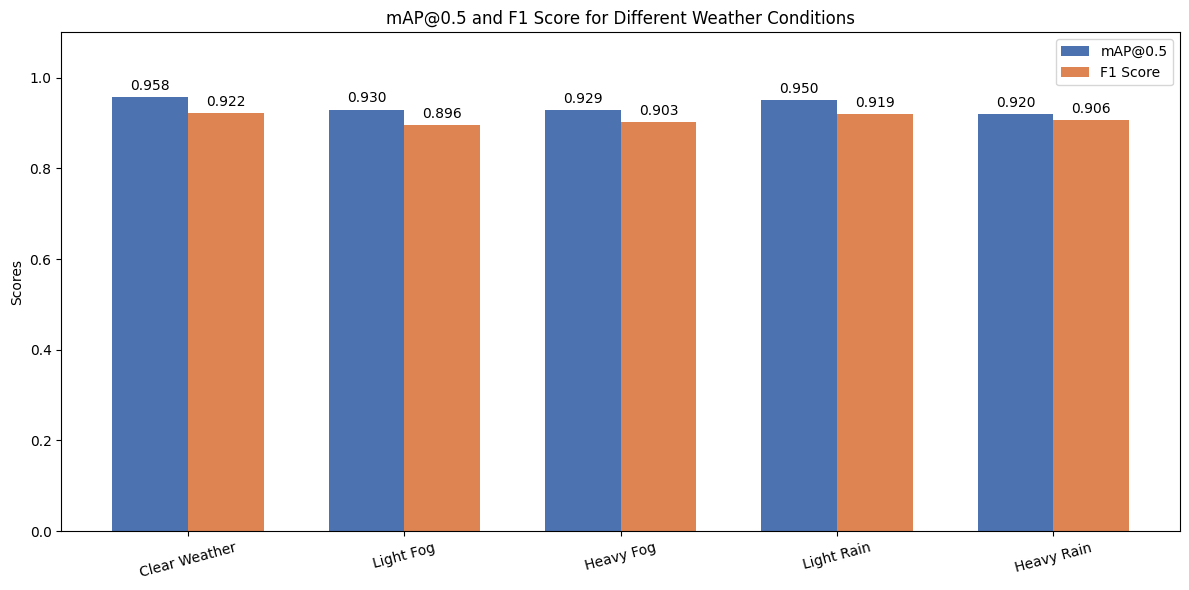

In [80]:
labels = list(results_summary.keys())

map_scores = [results_summary[w]['mAP50'] for w in labels]
f1_scores = [results_summary[w]['F1'] for w in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, map_scores, width, label='mAP@0.5', color='#4c72b0')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='#dd8452')

ax.set_ylabel('Scores')

ax.set_title('mAP@0.5 and F1 Score for Different Weather Conditions')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylim(0, 1.1)
ax.legend()

ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

fig.tight_layout()
plt.show()

In [87]:
import cv2
import torch
from tqdm.autonotebook import tqdm

input_video_path = '/kaggle/input/datasets/adithyamenonr/traffic-sign-video/test_rainy_video.mp4'
output_video_path = 'output_video.mp4'
conf_threshold = 0.75

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
model.to(device)

class_names = ['background', 'crosswalk', 'speedlimit', 'stop', 'trafficlight']
colors = {
    1: (255, 0, 0),
    2: (0, 255, 0),
    3: (0, 0, 255),
    4: (0, 255, 255)
}

In [88]:
cap = cv2.VideoCapture(input_video_path)

if not cap.isOpened():
    print(f"Error: Could not open video at {input_video_path}")
else:
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    print(f"Processing video: {input_video_path}")
    print(f"Resolution: {width}x{height}, FPS: {fps}, Total Frames: {total_frames}")

    with torch.no_grad():
        for _ in tqdm(range(total_frames), desc="Detecting: "):
            ret, frame = cap.read()
            if not ret:
                break

            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img_tensor = torch.as_tensor(img_rgb, dtype=torch.float32).permute(2, 0, 1) / 255.0
            
            img_tensor = img_tensor.unsqueeze(0).to(device) 

            predictions = model(img_tensor)[0]
            
            boxes = predictions['boxes'].cpu().numpy()
            scores = predictions['scores'].cpu().numpy()
            labels = predictions['labels'].cpu().numpy()

            for box, score, label in zip(boxes, scores, labels):
                if score >= conf_threshold:
                    x1, y1, x2, y2 = map(int, box)
                    class_name = class_names[label] if label < len(class_names) else str(label)
                    color = colors.get(label, (255, 255, 255))
                    
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
                    
                    text = f"{class_name}: {score:.2f}"
                    (text_width, text_height), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                    
                    cv2.rectangle(frame, (x1, y1 - text_height - 10), (x1 + text_width, y1), color, -1)
                    
                    cv2.putText(frame, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

            out.write(frame)

    cap.release()
    out.release()
    print(f"Processed video saved to: {output_video_path}")

Processing video: /kaggle/input/datasets/adithyamenonr/traffic-sign-video/test_rainy_video.mp4
Resolution: 1280x720, FPS: 24, Total Frames: 192


Detecting:   0%|          | 0/192 [00:00<?, ?it/s]

Processed video saved to: output_video.mp4
